# 06 — LSTM-Based Price Prediction & Trading Strategy

## Objective
To apply an LSTM for sequence-based price prediction and evaluate trading performance.


In [74]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

data=pd.read_csv("data/sp500_2015_2024_clean_tuning.csv", parse_dates=["Date"], index_col="Date")

feature_cols=["Close", "Returns", "MA10", "MA20", "MA50", "MA100", "Close_lag1", "Close_lag5", "Volume", "Vol20"]
X=data[feature_cols]

y=(data["Close_tomorrow"]/data["Close"])-1




## Sequence Construction

In [75]:
lookback=30

def make_sequences(X_df, y_series, lookback = 30):
    X_list, y_list, idx_list = [], [], []
    for i in range(lookback, len(X_df)):
        X_list.append(X_df.iloc[i-lookback:i].values)
        y_list.append(y_series.iloc[i])
        idx_list.append(y_series.index[i])
    return np.array(X_list), np.array(y_list), np.array(idx_list)

X, y, idx = make_sequences(X_df, y_series, lookback)

split = int(len(X) * 0.8)

X_train_raw = X[:split]
X_test_raw  = X[split:]

y_train_raw = y[:split]
y_test_raw  = y[split:]

## Data Scaling


In [77]:
n_train, timesteps, n_features = X_train_raw.shape
n_test = X_test_raw.shape[0]

X_train_2d = X_train_raw.reshape(-1, n_features)
X_test_2d  = X_test_raw.reshape(-1, n_features)

scaler = StandardScaler()
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_test_2d_scaled  = scaler.transform(X_test_2d)

X_train_scaled = X_train_2d_scaled.reshape(n_train, timesteps, n_features)
X_test_scaled  = X_test_2d_scaled.reshape(n_test, timesteps, n_features)


X_train_seq = X_train_scaled
X_test_seq  = X_test_scaled

y_train_seq = y_train_raw
y_test_seq  = y_test_raw


X_train_seq.shape, X_test_seq.shape

((1548, 30, 10), (387, 30, 10))

## LSTM Architecture

In [78]:
model = Sequential([ 
    LSTM(50, return_sequences=True, input_shape=(lookback, 10)), 
    Dropout(0.2), 
    LSTM(50, return_sequences = False), 
    Dropout(0.2), 
    Dense(25), 
    Dense(1) ])

model.compile(optimizer='adam', loss='mse')## Model Training
print("Model created")

Model created


## Model Training

In [79]:
history = model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=1,
                    validation_data=(X_test_seq, y_test_seq), verbose=1)

print("LSTM training complete")
print(f"Final Loss: {history.history['loss'][-1]:.6f}")

Epoch 1/20
1548/1548 [==============================] - 66s 35ms/step - loss: 0.0019 - val_loss: 1.3731e-04
Epoch 2/20
1548/1548 [==============================] - 50s 32ms/step - loss: 2.4481e-04 - val_loss: 7.4566e-05
Epoch 3/20
1548/1548 [==============================] - 55s 36ms/step - loss: 2.6131e-04 - val_loss: 7.0279e-05
Epoch 4/20
1548/1548 [==============================] - 61s 39ms/step - loss: 2.5888e-04 - val_loss: 2.5704e-04
Epoch 5/20
1548/1548 [==============================] - 53s 34ms/step - loss: 2.3347e-04 - val_loss: 7.5039e-05
Epoch 6/20
1548/1548 [==============================] - 52s 34ms/step - loss: 2.1508e-04 - val_loss: 2.7849e-04
Epoch 7/20
1548/1548 [==============================] - 52s 34ms/step - loss: 2.1018e-04 - val_loss: 1.4550e-04
Epoch 8/20
1548/1548 [==============================] - 58s 37ms/step - loss: 1.9231e-04 - val_loss: 7.4674e-05
Epoch 9/20
1548/1548 [==============================] - 65s 42ms/step - loss: 1.8184e-04 - val_loss: 1.5433e

In [80]:
y_pred = model.predict(X_test_seq).flatten()
mse = np.mean((y_test_seq - y_pred.flatten())**2)
print(f"Test MSE : {mse:.6f}")

test_df=pd.DataFrame({'actual':y_test_seq, 'pred':y_pred.flatten()})
test_df.to_csv('lstm_predictions.csv')

13/13 [==============================] - 4s 25ms/step
Test MSE : 0.000061


## Strategy Backtesting


B&H: 33.5% | Strat: 34.0%


Text(0.5, 1.0, 'LSTM Backtest')

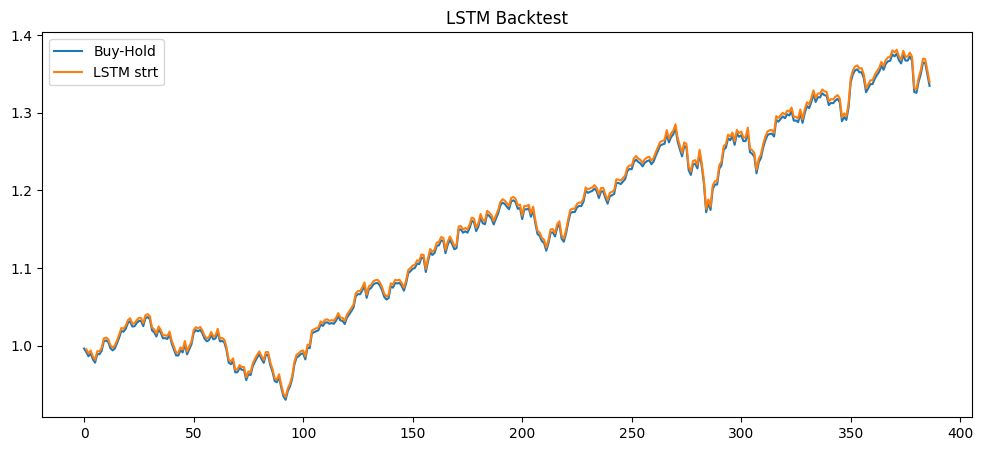

In [81]:
test_df['signal'] = np.where(test_df['pred'] > 0, 1, 0)
test_df['returns'] = test_df['actual']
test_df['signal']  = np.where(test_df['pred'] > 0, 1, 0) 
test_df['strat_ret'] = test_df['signal'].shift(1) * test_df['returns']
bh_ret    = (1 + test_df['returns']).prod() - 1
strat_ret = (1 + test_df['strat_ret'].dropna()).prod() - 1
print(f"B&H: {bh_ret*100:.1f}% | Strat: {strat_ret*100:.1f}%")

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
(1 + test_df['returns']).cumprod().plot(label="Buy-Hold")
(1 + test_df['strat_ret']).cumprod().plot(label="LSTM strt")
plt.legend(); plt.title("LSTM Backtest")

### Key Takeaways
- Low MSE ≠ tradable edge.
- LSTM generated no high-confidence trades.
